## Importing Libraries

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

### Loading Model

In [2]:
model = tf.keras.models.load_model('cnn_vit_crops_trained_model.keras')

In [3]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 5  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 224, 224, 32  1472        ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 max_pooling2d (MaxPooling2D)   (None, 112, 112, 32  0           ['conv2d[0][0]']                 
                                )                                                             

## Visualiasing Single Image of Test Set

In [4]:
!pip install opencv-python

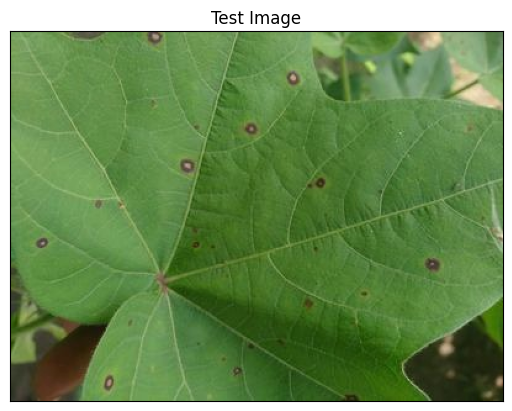

In [12]:
import cv2
image_path = "test/CottonTarget_spot/constract_high_4.jpg"
#Reading Image
img = cv2.imread(image_path)
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB) #Convert BGR image to RGB

#Displaying Image
plt.imshow(img)
plt.title("Test Image")
plt.xticks([])
plt.yticks([])
plt.show()

In [13]:
import os

print(image_path)
print(os.path.exists(image_path))  # Should return True

test/CottonTarget_spot/constract_high_4.jpg
True


## Testing Model

In [14]:
import tensorflow as tf
import numpy as np

# Load image in RGB (3 channels)
image = tf.keras.preprocessing.image.load_img(image_path, target_size=(224,224))
input_arr = tf.keras.preprocessing.image.img_to_array(image)  # shape (224,224,3)

# Add 2 extra dummy channels (zeros)
extra_channels = np.zeros((224,224,2), dtype=np.float32)  # shape (224,224,2)

# Concatenate -> final shape (224,224,5)
input_arr = np.concatenate([input_arr, extra_channels], axis=-1)

# Add batch dimension -> (1,224,224,5)
input_arr = np.expand_dims(input_arr, axis=0)

print(input_arr.shape)  # should print (1,224,224,5)

(1, 224, 224, 5)


In [15]:
prediction = model.predict(input_arr)
prediction,prediction.shape

1/1 [==============================] - 0s 33ms/step


(array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]],
       dtype=float32),
 (1, 16))

In [16]:
result_index = np.argmax(prediction)
result_index

9

In [17]:
class_name = ['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'CottonAphids',
 'CottonArmy_worm',
 'CottonBacterial_Blight',
 'CottonHealthy',
 'CottonPowdery_Mildew',
 'CottonTarget_spot',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'RoseBlack Spot',
 'RoseDowny Mildew',
 'RoseFresh Leaf']

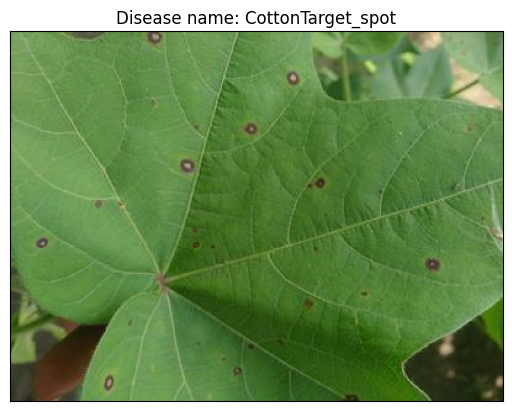

In [18]:
#Displaying Result of disease prediction
model_prediction = class_name[result_index]
plt.imshow(img)
plt.title(f"Disease name: {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()